In [ ]:
import pandas as pd #loading data
import numpy as np #Math Calcs
import re #RegularExpressions cleaning the data
import nltk #for basics
import matplotlib.pyplot as plt #visualitions
from nltk.corpus import stopwords # to remove be verbs unwanted words
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud

nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

print("customer reviews datasets")
print(df.head())

customer reviews datasets
                                              Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                  Amazing product. Worth the money.


In [ ]:
# Stopwords
stop_words = set(stopwords.words('english'))

# Text Cleaning Function
def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Join words back into a sentence
    cleaned_text = " ".join(words)

    return cleaned_text

# Apply cleaning
df['Cleaned_Review'] = df['Review'].apply(clean_text)

print("\nCleaned Reviews:")
print(df[['Review', 'Cleaned_Review']])


Cleaned Reviews:
                                              Review  \
0  The product quality is excellent and delivery ...   
1       Very bad packaging and the item was damaged.   
2       Customer service was helpful and responsive.   
3  The delivery was delayed and support team did ...   
4                  Amazing product. Worth the money.   
5      Poor quality product and terrible experience.   
6                  Fast shipping and good packaging.   
7        The product stopped working after two days.   
8               Excellent service and great quality.   
9            Late delivery and bad customer support.   

                             Cleaned_Review  
0   product quality excellent delivery fast  
1                bad packaging item damaged  
2       customer service helpful responsive  
3     delivery delayed support team respond  
4               amazing product worth money  
5  poor quality product terrible experience  
6              fast shipping good packaging

In [ ]:
sia=SentimentIntensityAnalyzer()

def analyze_sentiment(review):
  score=sia.polarity_scores(review)

  compound=score['compound']

  if compound >=0.05:
    return "positive"

  elif compound <=-0.05:
    return "Negative"

  else:
    return "neutral"

#Apply sentiment analysis
df['Sentiment']=df['Cleaned_Review'].apply(analyze_sentiment)


print("\nSentiment Analysis Results")
print(df[['Review','Sentiment']])


Sentiment Analysis Results
                                              Review Sentiment
0  The product quality is excellent and delivery ...  positive
1       Very bad packaging and the item was damaged.  Negative
2       Customer service was helpful and responsive.  positive
3  The delivery was delayed and support team did ...  positive
4                  Amazing product. Worth the money.  positive
5      Poor quality product and terrible experience.  Negative
6                  Fast shipping and good packaging.  positive
7        The product stopped working after two days.  Negative
8               Excellent service and great quality.  positive
9            Late delivery and bad customer support.  Negative


In [ ]:
all_words=" ".join(df['Cleaned_Review'])

word_list=all_words.split()

#count word journey
word_freq=Counter(word_list)

#Display top 10 keywords
print("\nTop 10 common keywords")
print(word_freq.most_common(10))


Top 10 common keywords
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


In [ ]:
negative_reviews=df[df['Sentiment']=='Negative']

negative_words=" ".join(negative_reviews['Cleaned_Review'])

negative_word_list=negative_words.split()

complaint_freq=Counter(negative_word_list)

print("\nMost common complained")
print(complaint_freq.most_common(10))


Most common complained
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


In [ ]:
sentiment_counts = df['Sentiment'].value_counts()
sentiment_counts

,count
Sentiment,
positive,6
Negative,4


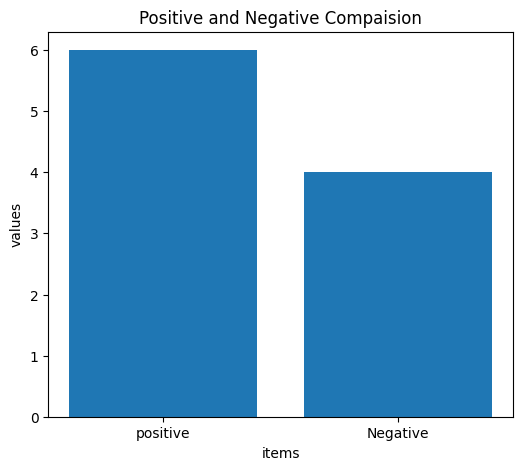

In [ ]:
sentiment_counts = df['Sentiment']. value_counts()
plt.figure(figsize=(6,5))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title("Positive and Negative Compaision")
plt.xlabel("items")
plt.ylabel("values")
plt.show()

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

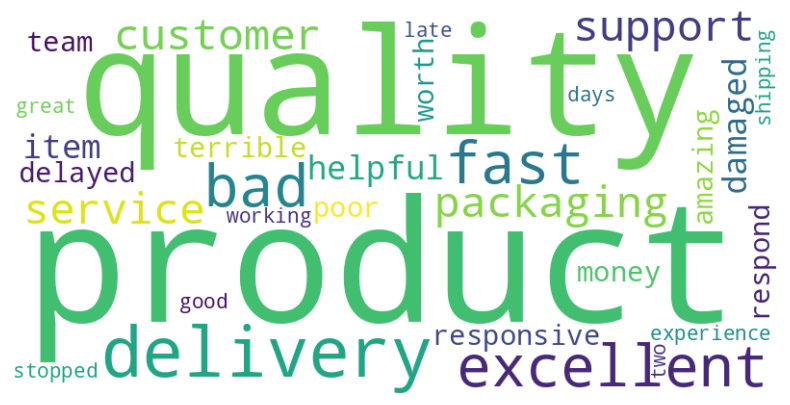

In [ ]:
wordcloud = WordCloud(
    width = 800,
    height = 400,
    background_color = 'white'
).generate(all_words)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')